In [2]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import (
    LinearRegression,
    Ridge
)

from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import (
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings('ignore')

In [3]:
housing = fetch_california_housing()

df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

df["HousePrice"] = housing.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
print("Shape:", df.shape)

df.info()

df.describe()

Shape: (20640, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   HousePrice  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [5]:
#Missing Values
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
HousePrice    0
dtype: int64

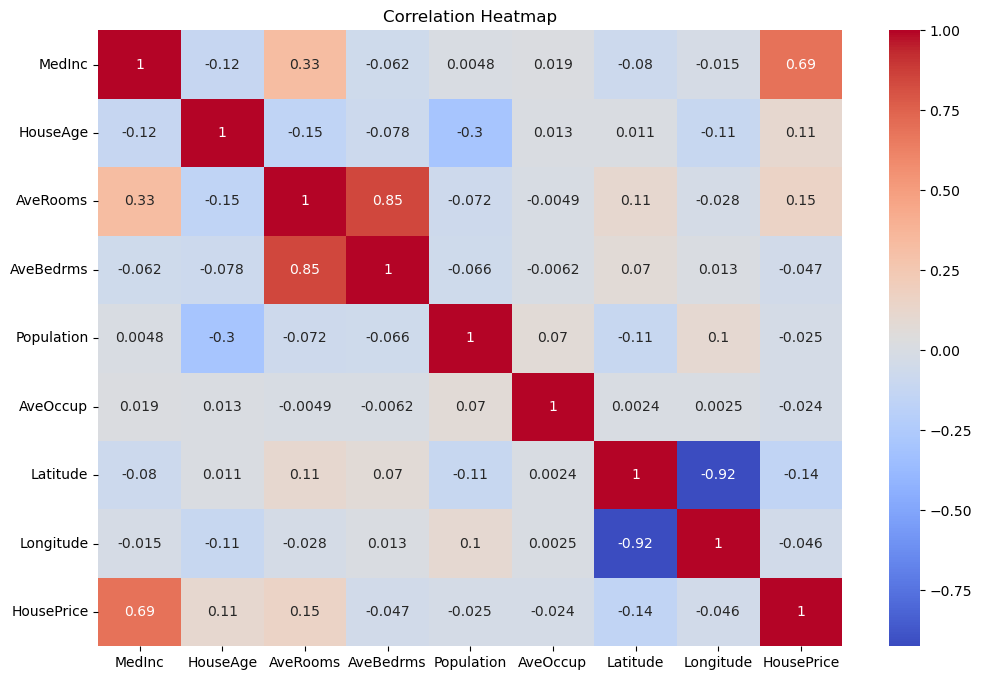

In [6]:
#Correlation Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [7]:
#Feature Selection
X = df.drop(
    "HousePrice",
    axis=1
)

y = df["HousePrice"]

In [8]:
#Feature Scaling 
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [9]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
#Detect Overfitting (Before Tuning)
tree = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)

tree.fit(
    X_train,
    y_train
)

train_pred = tree.predict(X_train)

test_pred = tree.predict(X_test)

train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        train_pred
    )
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        test_pred
    )
)

print("Training RMSE:", train_rmse)
print("Testing RMSE:", test_rmse)

Training RMSE: 0.6959477541460324
Testing RMSE: 0.7242338143386247


In [11]:
#Define Models
models = {

    "Linear Regression":
    LinearRegression(),

    "Ridge Regression":
    Ridge(alpha=1.0),

    "Decision Tree":
    DecisionTreeRegressor(
        max_depth=5,
        random_state=42
    )
}

In [12]:
#Train Models + Cross Validation
results = []

for name, model in models.items():

    model.fit(
        X_train,
        y_train
    )

    predictions = model.predict(
        X_test
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    cv_scores = cross_val_score(
        model,
        X_scaled,
        y,
        cv=5,
        scoring='r2'
    )

    results.append([

        name,

        rmse,

        r2,

        cv_scores.mean()
    ])

    print("\n", name)

    print("CV Scores:", cv_scores)

    print("Mean CV Score:", cv_scores.mean())


 Linear Regression
CV Scores: [0.54866323 0.46820691 0.55078434 0.53698703 0.66051406]
Mean CV Score: 0.5530311140279558

 Ridge Regression
CV Scores: [0.54876544 0.4681845  0.55080175 0.53691622 0.66052317]
Mean CV Score: 0.5530382161908902

 Decision Tree
CV Scores: [0.32603463 0.52499182 0.60290742 0.31954034 0.53355785]
Mean CV Score: 0.46140641222621015


In [13]:
#Save Cross Validation Results
cv_results_df = pd.DataFrame({

    "Fold": [1,2,3,4,5],

    "CV_R2_Score": cv_scores
})

cv_results_df

,Fold,CV_R2_Score
0,1,0.326035
1,2,0.524992
2,3,0.602907
3,4,0.319540
4,5,0.533558


In [14]:
cv_results_df.to_csv(
    "cross_validation_results.csv",
    index=False
)

In [15]:
#Hyperparameter Tuning
param_grid = {

    'max_depth':[3,5,7,10],

    'min_samples_split':[2,5,10],

    'min_samples_leaf':[1,2,4]
}

grid_search = GridSearchCV(

    DecisionTreeRegressor(
        random_state=42
    ),

    param_grid,

    cv=5,

    scoring='r2'
)

grid_search.fit(
    X_train,
    y_train
)

,estimator,DecisionTreeR...ndom_state=42)
,param_grid,"{'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


In [16]:
#Hypermeter Results
print(
    "Best Parameters:"
)

print(
    grid_search.best_params_
)

print(
    "Best CV Score:"
)

print(
    grid_search.best_score_
)

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best CV Score:
0.7104874238620574


In [17]:
tuning_results = pd.DataFrame(
    grid_search.cv_results_
)

tuning_results.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_leaf,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.046273,0.001124,0.001562,0.000245,3,1,2,"{'max_depth': 3, 'min_samples_leaf': 1, 'min_s...",0.522631,0.536997,0.534613,0.51512,0.521831,0.526238,0.00827,28
1,0.046087,0.001053,0.001609,0.000391,3,1,5,"{'max_depth': 3, 'min_samples_leaf': 1, 'min_s...",0.522631,0.536997,0.534613,0.51512,0.521831,0.526238,0.00827,28
2,0.047173,0.001678,0.002158,0.000503,3,1,10,"{'max_depth': 3, 'min_samples_leaf': 1, 'min_s...",0.522631,0.536997,0.534613,0.51512,0.521831,0.526238,0.00827,28
3,0.047201,0.001618,0.001230,0.000178,3,2,2,"{'max_depth': 3, 'min_samples_leaf': 2, 'min_s...",0.522631,0.536997,0.534613,0.51512,0.521831,0.526238,0.00827,28
4,0.045575,0.002684,0.001316,0.000118,3,2,5,"{'max_depth': 3, 'min_samples_leaf': 2, 'min_s...",0.522631,0.536997,0.534613,0.51512,0.521831,0.526238,0.00827,28


In [18]:
tuning_results.to_csv(
    "hyperparameter_tuning_results.csv",
    index=False
)

In [19]:
#Evaluate Tuned Model
best_model = grid_search.best_estimator_

best_model.fit(
    X_train,
    y_train
)

best_pred = best_model.predict(
    X_test
)

best_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        best_pred
    )
)

best_r2 = r2_score(
    y_test,
    best_pred
)

best_cv = cross_val_score(
    best_model,
    X_scaled,
    y,
    cv=5,
    scoring='r2'
).mean()

In [20]:
#Overfitting Check After Tuning 
tuned_train_pred = best_model.predict(
    X_train
)

tuned_test_pred = best_model.predict(
    X_test
)

tuned_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        tuned_train_pred
    )
)

tuned_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tuned_test_pred
    )
)

print(
    "Tuned Train RMSE:",
    tuned_train_rmse
)

print(
    "Tuned Test RMSE:",
    tuned_test_rmse
)

Tuned Train RMSE: 0.4865960136384907
Tuned Test RMSE: 0.6389361233642388


In [21]:
print("\nOverfitting Analysis")

if abs(tuned_train_rmse - tuned_test_rmse) < 0.2:
    print("Model shows good generalization and controlled overfitting.")
else:
    print("Model may still show signs of overfitting.")


Overfitting Analysis
Model shows good generalization and controlled overfitting.


In [33]:
overfitting_df = pd.DataFrame({

    "Model":[
        "Before Tuning",
        "After Tuning"
    ],

    "Train RMSE":[
        train_rmse,
        tuned_train_rmse
    ],

    "Test RMSE":[
        test_rmse,
        tuned_test_rmse
    ]
})

overfitting_df

,Model,Train RMSE,Test RMSE
0,Before Tuning,0.695948,0.724234
1,After Tuning,0.486596,0.638936


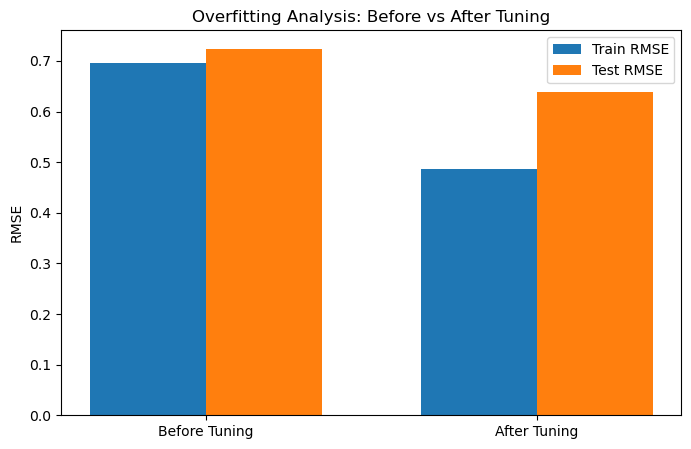

In [34]:
plt.figure(figsize=(8,5))

x = np.arange(len(overfitting_df))

width = 0.35

plt.bar(
    x - width/2,
    overfitting_df["Train RMSE"],
    width,
    label="Train RMSE"
)

plt.bar(
    x + width/2,
    overfitting_df["Test RMSE"],
    width,
    label="Test RMSE"
)

plt.xticks(
    x,
    overfitting_df["Model"]
)

plt.ylabel("RMSE")

plt.title(
    "Overfitting Analysis: Before vs After Tuning"
)

plt.legend()

plt.show()

In [22]:
#Add Tuned Model to Comparision
results.append([

    "Tuned Decision Tree",

    best_rmse,

    best_r2,

    best_cv
])

In [23]:
comparison_df = pd.DataFrame(

    results,

    columns=[

        "Model",

        "RMSE",

        "R2 Score",

        "Mean CV Score"
    ]
)

comparison_df = comparison_df.sort_values(

    by="R2 Score",

    ascending=False
)

comparison_df

,Model,RMSE,R2 Score,Mean CV Score
3,Tuned Decision Tree,0.638936,0.688464,0.520382
2,Decision Tree,0.724234,0.599732,0.461406
1,Ridge Regression,0.745554,0.575819,0.553038
0,Linear Regression,0.745581,0.575788,0.553031


In [24]:
comparison_df.to_csv(
    "model_comparison_table.csv",
    index=False
)

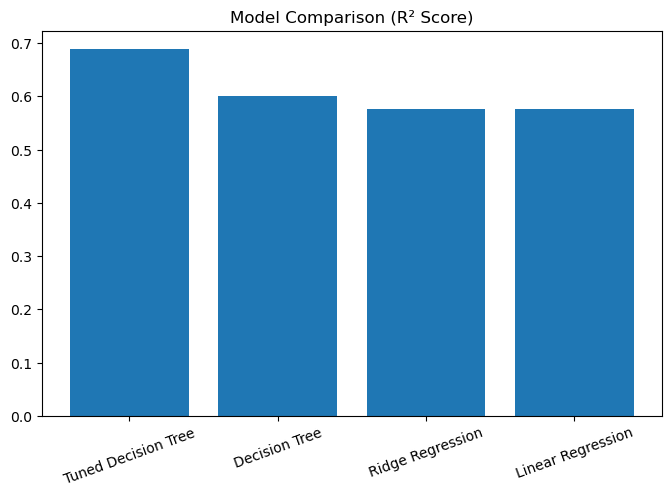

In [26]:
#Model Comparison Chart
plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["R2 Score"]
)

plt.title(
    "Model Comparison (R² Score)"
)

plt.xticks(rotation=20)

plt.show()

In [35]:
train_r2_before = tree.score(
    X_train,
    y_train
)

test_r2_before = tree.score(
    X_test,
    y_test
)

train_r2_after = best_model.score(
    X_train,
    y_train
)

test_r2_after = best_model.score(
    X_test,
    y_test
)

r2_df = pd.DataFrame({

    "Model":[
        "Before Tuning",
        "After Tuning"
    ],

    "Train R2":[
        train_r2_before,
        train_r2_after
    ],

    "Test R2":[
        test_r2_before,
        test_r2_after
    ]
})

r2_df

,Model,Train R2,Test R2
0,Before Tuning,0.637679,0.599732
1,After Tuning,0.822876,0.688464


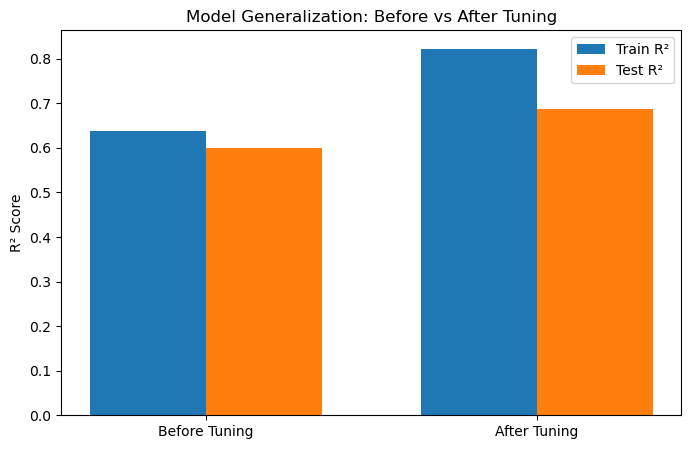

In [36]:
plt.figure(figsize=(8,5))

x = np.arange(len(r2_df))

width = 0.35

plt.bar(
    x - width/2,
    r2_df["Train R2"],
    width,
    label="Train R²"
)

plt.bar(
    x + width/2,
    r2_df["Test R2"],
    width,
    label="Test R²"
)

plt.xticks(
    x,
    r2_df["Model"]
)

plt.ylabel("R² Score")

plt.title(
    "Model Generalization: Before vs After Tuning"
)

plt.legend()

plt.show()

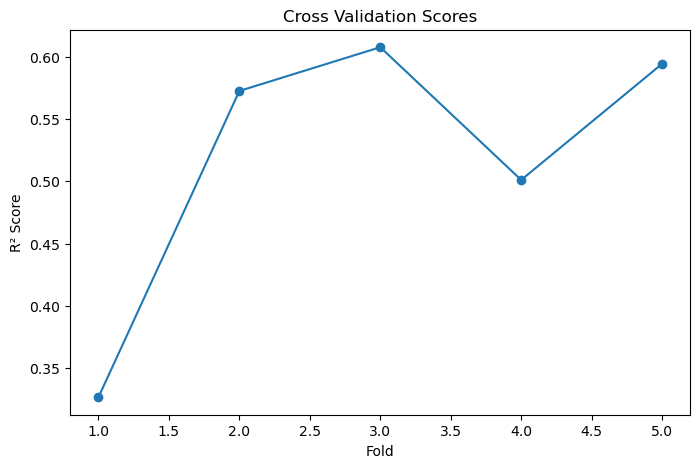

In [27]:
#Cross Validation Plot
cv_scores = cross_val_score(

    best_model,

    X_scaled,

    y,

    cv=5,

    scoring='r2'
)

plt.figure(figsize=(8,5))

plt.plot(

    range(1,6),

    cv_scores,

    marker='o'
)

plt.title(
    "Cross Validation Scores"
)

plt.xlabel("Fold")

plt.ylabel("R² Score")

plt.show()

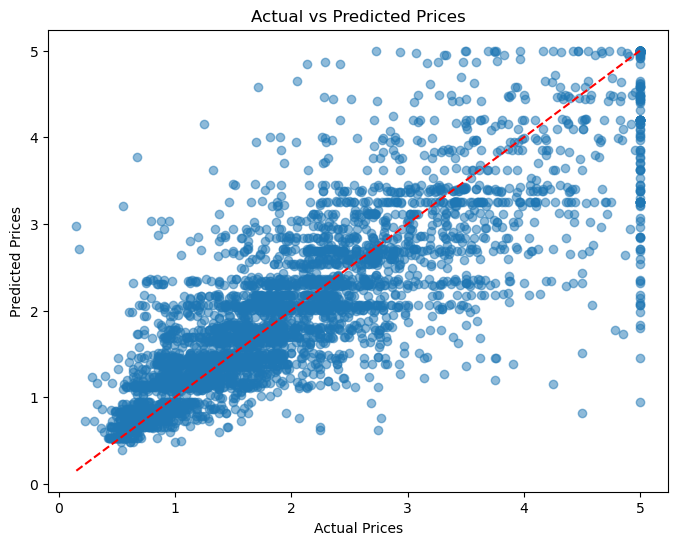

In [28]:
#Actual vs Predicted
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    best_pred,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Prices")

plt.ylabel("Predicted Prices")

plt.title(
    "Actual vs Predicted Prices"
)

plt.show()

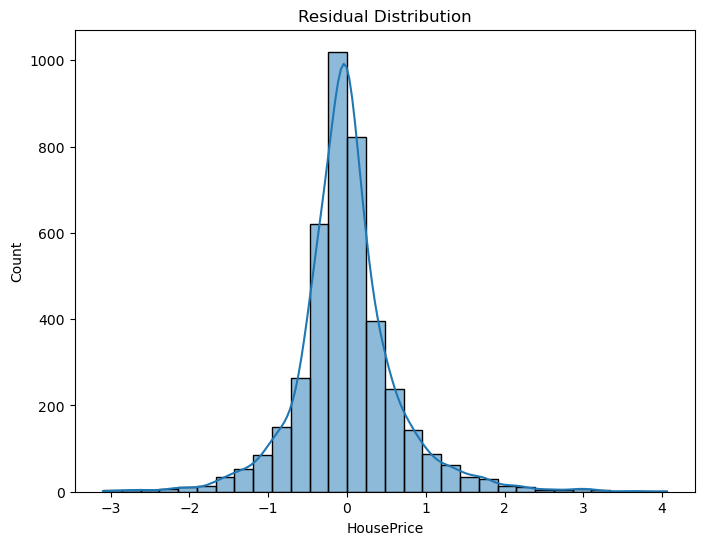

In [29]:
#Residual Distribution
residuals = y_test - best_pred

plt.figure(figsize=(8,6))

sns.histplot(
    residuals,
    bins=30,
    kde=True
)

plt.title(
    "Residual Distribution"
)

plt.show()

In [30]:
#Feature Importance
importance = pd.DataFrame({

    "Feature":
    X.columns,

    "Importance":
    best_model.feature_importances_
})

importance = importance.sort_values(

    by="Importance",

    ascending=False
)

importance

,Feature,Importance
0,MedInc,0.617018
5,AveOccup,0.131007
6,Latitude,0.079174
7,Longitude,0.065475
1,HouseAge,0.044928
2,AveRooms,0.037535
4,Population,0.013128
3,AveBedrms,0.011734


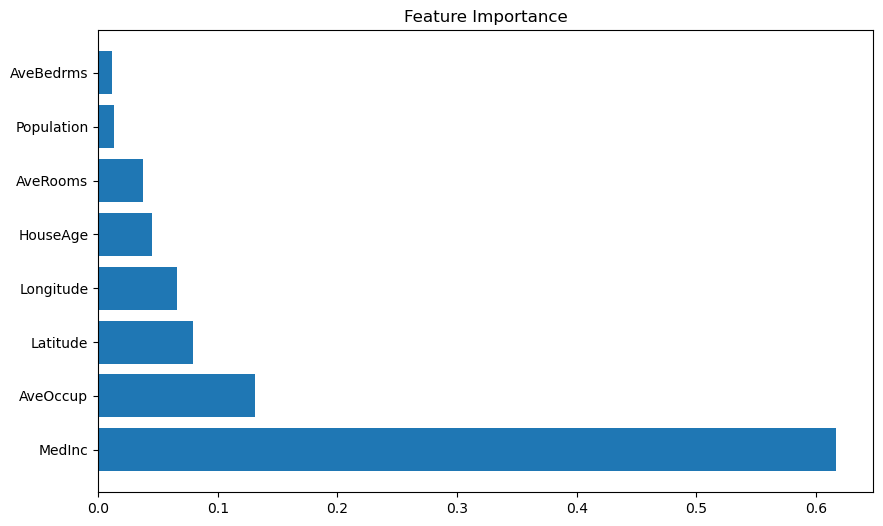

In [31]:
#Feature Importance Plot
plt.figure(figsize=(10,6))

plt.barh(

    importance["Feature"],

    importance["Importance"]
)

plt.title(
    "Feature Importance"
)

plt.show()

In [32]:
#Save Final Model
joblib.dump(
    best_model,
    "best_model_task3.joblib"
)

print(
    "Model Saved Successfully"
)

Model Saved Successfully


In [ ]:
#Final Model Selection Justification
The Tuned Decision Tree Regressor was selected as the final model because it achieved strong predictive performance and reliable cross-validation results.

Overfitting was reduced using GridSearchCV by tuning:
- max_depth
- min_samples_split
- min_samples_leaf

Cross-validation provided consistent performance across multiple folds, making the results more trustworthy than a single train-test split.

Although Linear Regression and Ridge Regression are simpler and easier to interpret, the Tuned Decision Tree achieved better predictive accuracy while maintaining good generalization capability.

Therefore, the Tuned Decision Tree Regressor was selected as the final model for house price prediction.